--- 
## Analyse Descriptive Univariée

In [2]:
import sys
print(sys.executable)


c:\Users\Chloe\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [4]:
df = pd.read_excel("Base_ER_FR.xlsx")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH',
       'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'Unnamed: 19'],
      dtype='str')

In [5]:
print("Observations initiales :", len(df))
df = df.drop(columns=["Unnamed: 19"])

Observations initiales : 100000


VARIABLE ID : identifiant unique associe a chaque observation

In [6]:
print("Nombre de NA :", df["ID"].isna().sum())
print("Nombre de doublons :", df["ID"].duplicated().sum())
print("ID unique :", df["ID"].is_unique)


Nombre de NA : 0
Nombre de doublons : 0
ID unique : True


VARIABLE AGE_CLI : age du client

In [7]:
print("Nombre de NA :", df["AGE_CLI"].isna().sum())
len(df) - 476

Nombre de NA : 476


99524

In [8]:
df["AGE_CLI"].describe(percentiles=[0.25, 0.5, 0.75])

count    99524.000000
mean        51.958472
std         14.941231
min         18.000000
25%         40.000000
50%         52.000000
75%         64.000000
max         92.000000
Name: AGE_CLI, dtype: float64

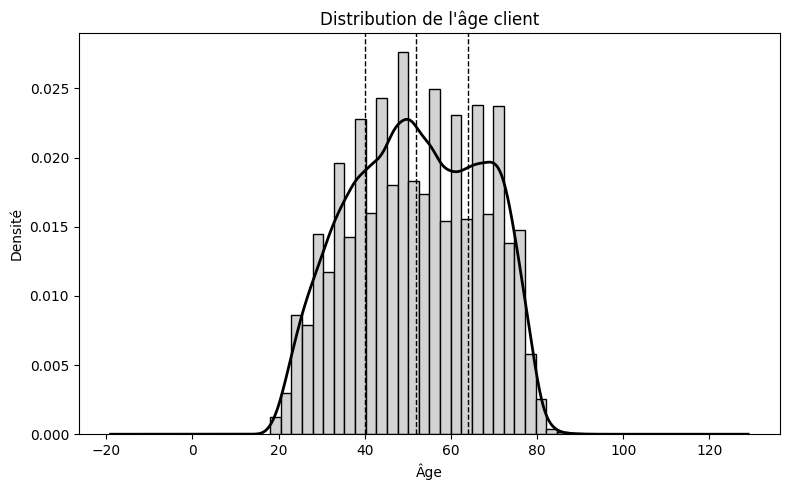

In [9]:
age = df["AGE_CLI"].dropna()

# quartiles
q25, q50, q75 = np.percentile(age, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(age, bins=30, density=True, color="lightgrey", edgecolor="black")

age.plot(kind="density", color="black", linewidth=2)
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de l'âge client")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()


In [10]:
print(
    f"L'âge des clients est compris entre {int(age.min())} et {int(age.max())} ans. "
    f"La distribution est centrée autour de {int(q50)} ans, avec des premier et "
    f"troisième quartiles respectivement égaux à {int(q25)} et {int(q75)} ans. "
)


L'âge des clients est compris entre 18 et 92 ans. La distribution est centrée autour de 52 ans, avec des premier et troisième quartiles respectivement égaux à 40 et 64 ans. 


VARIABLE B_MAT : maturite initiale du credit, exprimee en mois

In [11]:
print("Nombre de NA :", df["B_MAT"].isna().sum())
len(df) - 1380

Nombre de NA : 1380


98620

In [12]:
df["B_MAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        70.807585
std         43.506068
min          0.000000
25%         48.000000
50%         61.000000
75%         78.250000
max        300.000000
Name: B_MAT, dtype: float64

Traitement valeur extrême :

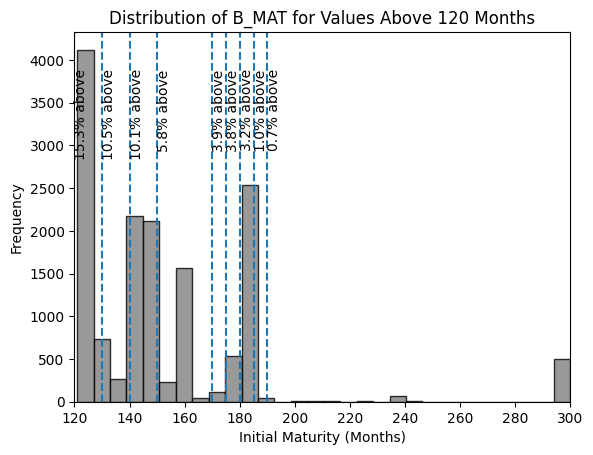

In [13]:
import matplotlib.pyplot as plt
import numpy as np

seuil_min = 120
thresholds = [120, 130, 140, 150, 170, 175, 180, 185, 190]

data = df["B_MAT"].dropna()
subset = data[data > seuil_min]

total = len(data)

plt.figure()

# Histogram restricted to values > 120
plt.hist(subset, bins=30, color="grey", edgecolor="black", alpha=0.8)

# Vertical lines + percentages above each threshold
for threshold in thresholds:
    pct_above = (data > threshold).mean() * 100
    
    plt.axvline(threshold, linestyle="--")
    
    plt.text(
        threshold,
        plt.ylim()[1] * 0.9,
        f"{pct_above:.1f}% above",
        rotation=90,
        verticalalignment="top"
    )

plt.title("Distribution of B_MAT for Values Above 120 Months")
plt.xlabel("Initial Maturity (Months)")
plt.ylabel("Frequency")

plt.xlim(seuil_min, subset.max())

plt.show()


In [14]:
df = df[(df["B_MAT"] <= 170) | (df["B_MAT"].isna())]


In [15]:
print(len(df) )


96179


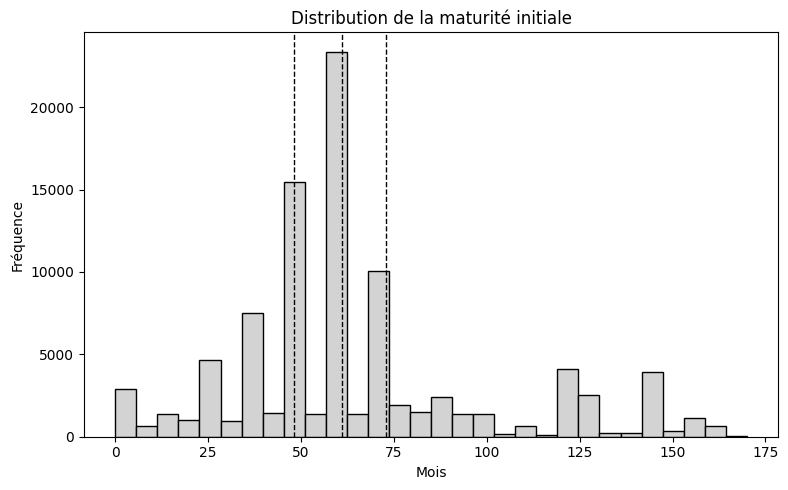

In [16]:
bmat = df["B_MAT"].dropna()
q25, q50, q75 = np.percentile(bmat, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(bmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité initiale")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

In [17]:
print(df["B_MAT"].describe(percentiles=[0.25, 0.5, 0.75]))


count    94799.000000
mean        65.598044
std         34.705058
min          0.000000
25%         48.000000
50%         61.000000
75%         73.000000
max        170.000000
Name: B_MAT, dtype: float64


VARIABLE B_RESMAT : maturite residuelle du credit (duree restante jusqu’a l’echeance d’un
credit), exprimee en mois

In [18]:
print(df["B_RESMAT"].describe(percentiles=[0.25, 0.5, 0.75]))
print(df["B_RESMAT"].isna().sum())



count    94799.000000
mean        33.188283
std         31.816710
min          0.000000
25%          7.000000
50%         26.000000
75%         48.000000
max        167.000000
Name: B_RESMAT, dtype: float64
1380


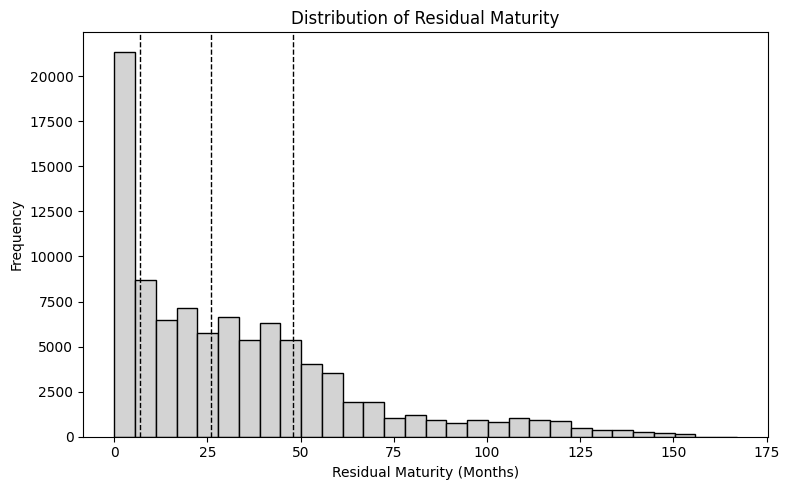

In [19]:
bresmat = df["B_RESMAT"].dropna()
q25, q50, q75 = np.percentile(bresmat, [25, 50, 75])

plt.figure(figsize=(8, 5))
plt.hist(bresmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)

plt.title("Distribution of Residual Maturity")
plt.xlabel("Residual Maturity (Months)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


VARIABLE CLASSACT : classe d'actif

VARIABLE CSP : catégorie socio profesionnel (regroupement à traiter)

VARIABLE DARRET : date d’arret ou de reference associee au credit.

In [20]:
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str),
    format="%Y%m",
    errors="coerce"
)
df["DARRET"].describe()


count                         96179
mean     2021-03-06 13:49:25.408249
min             2019-01-01 00:00:00
25%             2019-12-01 00:00:00
50%             2021-03-01 00:00:00
75%             2022-05-01 00:00:00
max             2023-12-01 00:00:00
Name: DARRET, dtype: object

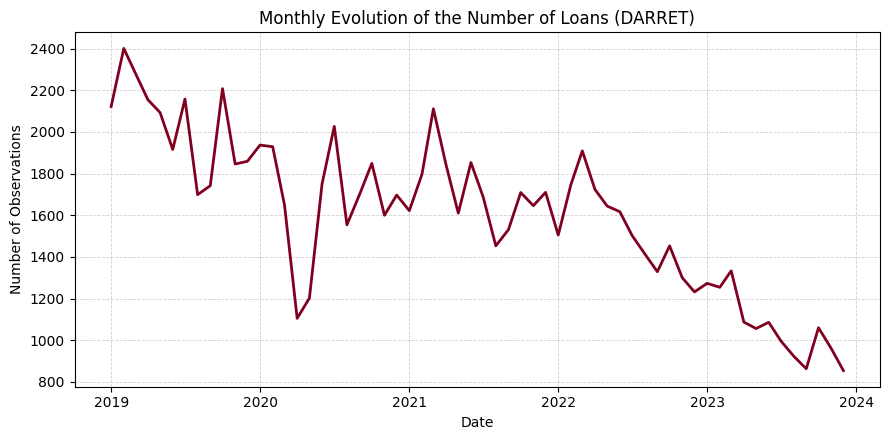

In [21]:
monthly_counts = (
    df
    .groupby(df["DARRET"].dt.to_period("M").dt.to_timestamp())
    .size()
    .reset_index(name="n_obs")
    .rename(columns={"DARRET": "DARRET_M"})
)

plt.figure(figsize=(9, 4.5))

plt.plot(
    monthly_counts["DARRET_M"],
    monthly_counts["n_obs"],
    color="#800020",      # burgundy
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.title("Monthly Evolution of the Number of Loans (DARRET)")

plt.grid(
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()
plt.show()


VARIABLE E_EAD :  exposition au defaut du contrat 

In [22]:
df["E_EAD"].describe(percentiles=[0.25, 0.5, 0.75])


count     94799.000000
mean        860.754398
std        4650.698061
min           0.000000
25%           0.000000
50%           0.000000
75%           0.180000
max      226089.670000
Name: E_EAD, dtype: float64

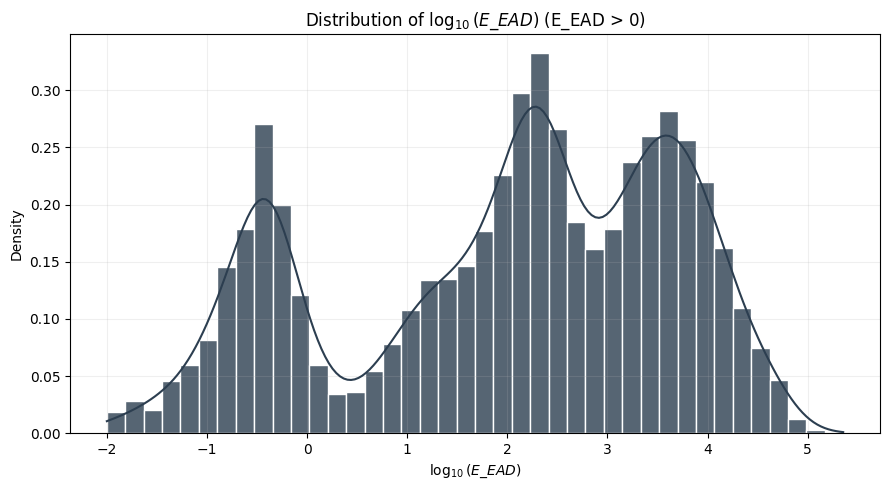

In [23]:
ead_positive = df.loc[df["E_EAD"] > 0, "E_EAD"]
log_ead_positive = np.log10(ead_positive)

plt.figure(figsize=(9, 5))

sns.histplot(
    log_ead_positive,
    bins=40,
    stat="density",
    kde=True,
    color="#2C3E50",
    edgecolor="white",
    alpha=0.8
)

plt.xlabel(r"$\log_{10}(E\_EAD)$")
plt.ylabel("Density")
plt.title("Distribution of $\log_{10}(E\_EAD)$ (E_EAD > 0)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


VARIABLE E_OFF : exposition hors bilan associee au credit

In [24]:
df["E_OFF"].describe()

count    94799.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: E_OFF, dtype: float64

VARIABLE E_ONB : montant du bilan

In [25]:
(df["E_ONB"].fillna(0) == df["E_EAD"].fillna(0)).all()


np.True_

VARIABLE MREVAU : montant autre revenu client

In [26]:
df["MREVAU"].describe(percentiles=[0.25, 0.5, 0.75])

count     96133.000000
mean         95.702849
std         877.537637
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      194096.000000
Name: MREVAU, dtype: float64

VARIABLE MREVNU : montant du revenu du client

In [27]:
df["MREVNU"].describe(percentiles=[0.25, 0.5, 0.75])

count     96133.000000
mean       2446.179522
std        2844.213728
min           0.000000
25%        1530.000000
50%        2003.000000
75%        2778.000000
max      265000.000000
Name: MREVNU, dtype: float64

VARIABLE MREVTOT :  montant du revenu total du client

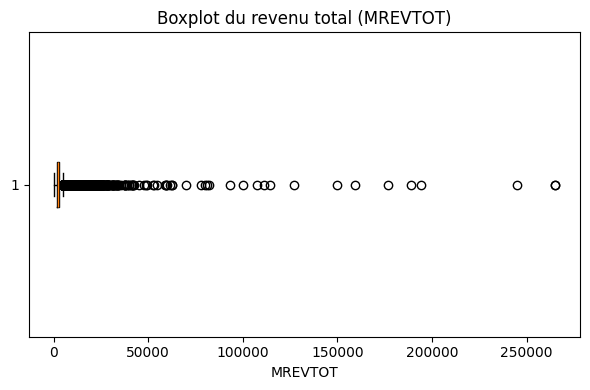

In [28]:
mrevtot = df["MREVTOT"].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(
    mrevtot,
    vert=False,
    showfliers=True
)
plt.xlabel("MREVTOT")
plt.title("Boxplot du revenu total (MREVTOT)")

plt.tight_layout()
plt.show()

VARIABLE MTECH : montant de l’echeance theorique du credit (le paiement periodique contractuel que le client est cense verser a chaque echeance (mensualite), hors evenement particulier)

In [29]:
df["MTECH"].describe(percentiles=[0.25, 0.5, 0.75])

count    96179.000000
mean       226.725037
std        254.002729
min          0.000000
25%         94.230000
50%        179.000000
75%        296.590000
max      35915.740000
Name: MTECH, dtype: float64

VARIABLE NBIMP :  nombre d’impayes observes sur le credit.

In [30]:
df["NBIMP"].describe(percentiles=[0.25, 0.5, 0.75])

count    96179.000000
mean         0.006186
std          0.126510
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: NBIMP, dtype: float64

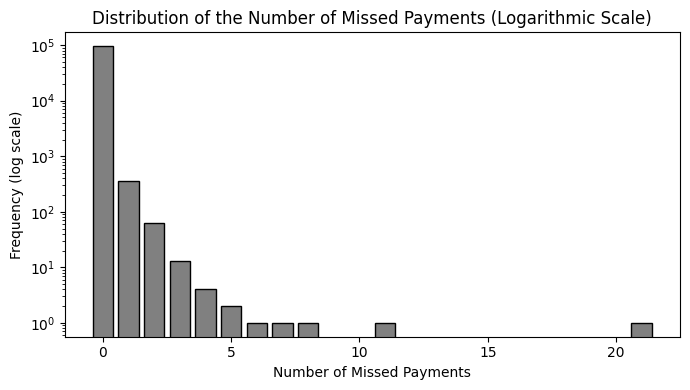

In [31]:
nbimp_counts = df["NBIMP"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(
    nbimp_counts.index,
    nbimp_counts.values,
    color="gray",
    edgecolor="black"
)

plt.yscale("log")
plt.xlabel("Number of Missed Payments")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of the Number of Missed Payments (Logarithmic Scale)")

plt.tight_layout()
plt.show()


VARIABLE NB_ECH : nombre total d’echeances prevues par le contrat.

In [32]:
df["NB_ECH"].describe(percentiles=[0.25, 0.5, 0.75])


count    96179.000000
mean        58.440054
std         35.237845
min          1.000000
25%         36.000000
50%         60.000000
75%         72.000000
max        180.000000
Name: NB_ECH, dtype: float64

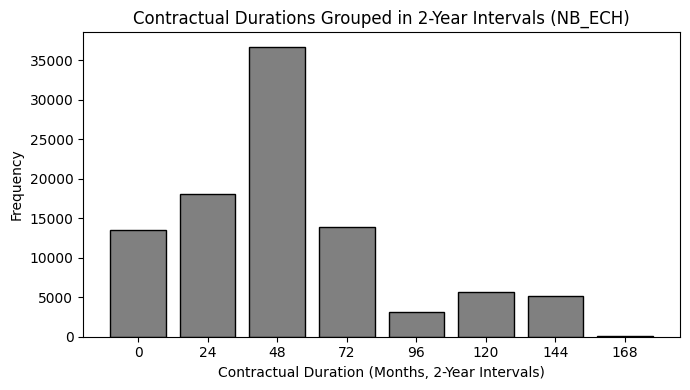

In [33]:
nb_ech_2y_counts = (
    (df["NB_ECH"] // 24 * 24)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    nb_ech_2y_counts.index.astype(str),
    nb_ech_2y_counts.values,
    color="grey",
    edgecolor="black"
)

plt.xlabel("Contractual Duration (Months, 2-Year Intervals)")
plt.ylabel("Frequency")
plt.title("Contractual Durations Grouped in 2-Year Intervals (NB_ECH)")

plt.tight_layout()
plt.show()


VARIABLE produit :  type de produit de credit

In [34]:
# Nombre total initial
n_initial = len(df)
print(n_initial)
# Nombre de contrats AR
n_ar = (df["produit"] == "AR").sum()

# Proportion supprimée
pct_ar = n_ar / n_initial * 100

print("Number of AR contracts removed:", n_ar)
print(f"Proportion removed: {pct_ar:.2f}%")

# Filtrage : on garde uniquement les AMO
df = df[df["produit"] != "AR"]

# Vérification
print("Observations remaining:", len(df))


96179
Number of AR contracts removed: 1564
Proportion removed: 1.63%
Observations remaining: 94615


VARIABLE RA :  montant du remboursement anticipe observe sur le credit

In [35]:
# Taille initiale
n_initial = len(df)
print(n_initial)
# Nombre de valeurs négatives
n_negative_RA = (df["RA"] < 0).sum()

# Proportion supprimée
pct_negative_RA = n_negative_RA / n_initial * 100

print("Negative RA observations:", n_negative_RA)
print(f"Proportion of the dataset: {pct_negative_RA:.2f}%")

# Suppression des valeurs négatives
df = df[df["RA"] >= 0]

print("Observations remaining:", len(df))


94615
Negative RA observations: 346
Proportion of the dataset: 0.37%
Observations remaining: 94269


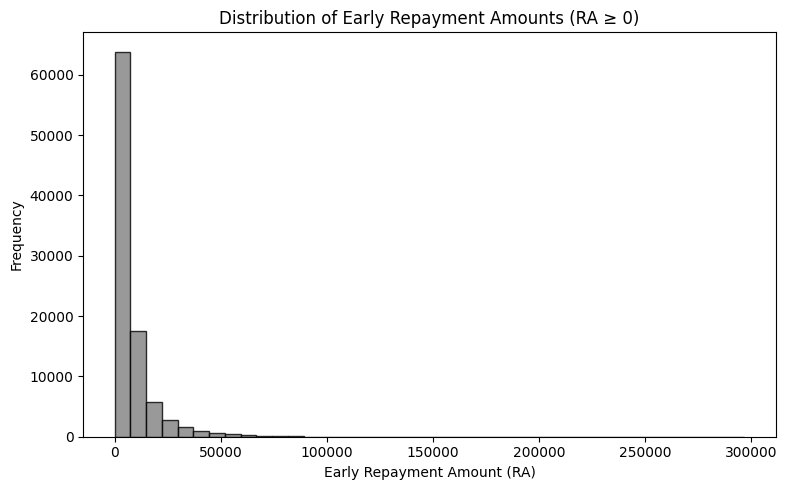

In [36]:
ra_clean = df["RA"]

plt.figure(figsize=(8, 5))

plt.hist(
    ra_clean,
    bins=40,
    color="grey",
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Early Repayment Amount (RA)")
plt.ylabel("Frequency")
plt.title("Distribution of Early Repayment Amounts (RA ≥ 0)")

plt.tight_layout()
plt.show()


VARIABLE Tx :  correspond au taux d’interet contractuel du credit

In [37]:
# Taille initiale
n_initial = len(df)
print(n_initial)
# Nombre de taux négatifs
n_negative_tx = (df["Tx"] < 0).sum()
pct_negative_tx = n_negative_tx / n_initial * 100

print("Negative interest rates:", n_negative_tx)
print(f"Proportion of the dataset: {pct_negative_tx:.2f}%")

# Suppression
df = df[df["Tx"] >= 0]

print("Observations remaining:", len(df))


94269
Negative interest rates: 1622
Proportion of the dataset: 1.72%
Observations remaining: 88510


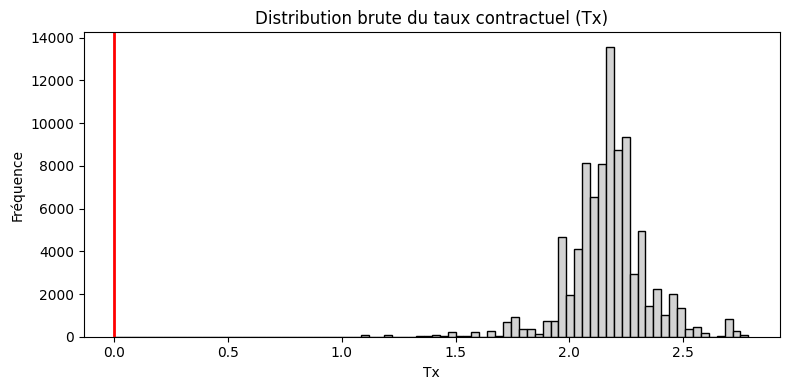

In [38]:
tx = df["Tx"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    tx,
    bins=80,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro (taux négatifs)
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution brute du taux contractuel (Tx)")

plt.tight_layout()
plt.show()

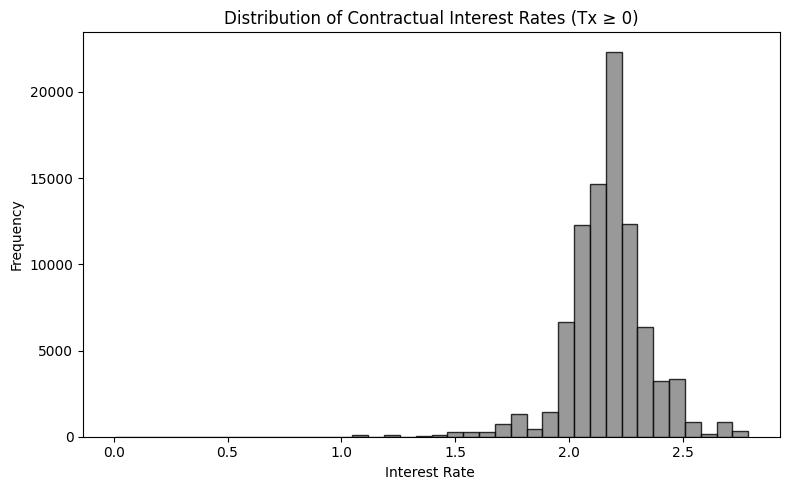

In [39]:
tx_positive = df["Tx"]

plt.figure(figsize=(8, 5))

plt.hist(
    tx_positive,
    bins=40,
    color="grey",
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Interest Rate ")
plt.ylabel("Frequency")
plt.title("Distribution of Contractual Interest Rates (Tx ≥ 0)")

plt.tight_layout()
plt.show()


In [40]:
# Nombre d'observations avec Tx < 0.5
nb_below_05 = (df["Tx"] < 0.5).sum()

# Proportion correspondante
prop_below_05 = (df["Tx"] < 0.5).mean()

print("Number of rates below 0.5:", nb_below_05)
print("Proportion:", prop_below_05)

df = df[df["Tx"] >= 0.5]


Number of rates below 0.5: 20
Proportion: 0.00022596316800361542


In [41]:
df["Tx"].describe(percentiles=[0.25, 0.5, 0.75])


count    88490.000000
mean         2.170199
std          0.176832
min          0.579181
25%          2.083425
50%          2.179337
75%          2.256484
max          2.786456
Name: Tx, dtype: float64

In [42]:
((100000-88490)/100000)*100

11.51

--- 

## Traitement des valeurs manquantes :

In [43]:
na_table = pd.DataFrame({
    "nb_na": df.isna().sum(),
    "pourcentage_na": df.isna().mean()
}).sort_values("pourcentage_na", ascending=False)

na_table

,nb_na,pourcentage_na
B_MAT,1302,0.014714
E_ONB,1302,0.014714
B_RESMAT,1302,0.014714
E_OFF,1302,0.014714
E_EAD,1302,0.014714
AGE_CLI,458,0.005176
CSP,117,0.001322
MREVTOT,42,0.000475
MREVAU,42,0.000475
MREVNU,42,0.000475


In [44]:
block = ["B_MAT", "B_RESMAT", "E_ONB", "E_OFF", "E_EAD"]

na_block = df[block].isna()
print("NA par variable (bloc) :")
print(na_block.sum())

print("Nombre de lignes où TOUT le bloc est manquant :", int(na_block.all(axis=1).sum()))
print("Nombre de lignes où AU MOINS une variable du bloc est manquante :", int(na_block.any(axis=1).sum()))

# Vérifier si c'est exactement les mêmes lignes (NA identiques)
same_rows = na_block.all(axis=1).sum() == na_block.any(axis=1).sum()
print("Bloc manquant exactement sur les mêmes lignes :", bool(same_rows))


NA par variable (bloc) :
B_MAT       1302
B_RESMAT    1302
E_ONB       1302
E_OFF       1302
E_EAD       1302
dtype: int64
Nombre de lignes où TOUT le bloc est manquant : 1302
Nombre de lignes où AU MOINS une variable du bloc est manquante : 1302
Bloc manquant exactement sur les mêmes lignes : True


In [45]:
# Age
df["AGE_MISSING"] = df["AGE_CLI"].isna().astype(int)
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())

# CSP
df["CSP"] = df["CSP"].fillna("Inconnu")

# B_MAT/ B_RESMAT/ E_EAD
df = df.dropna(subset=["B_MAT", "B_RESMAT", "E_EAD"])

# Revenus
df["MREVNU"] = df["MREVNU"].fillna(df["MREVNU"].median())
df["MREVAU"] = df["MREVAU"].fillna(df["MREVAU"].median())
df["MREVTOT"] = df["MREVNU"] + df["MREVAU"]


len(df)
((100000-87188)/100000)*100

12.812000000000001

--- 
## Création de Variables

Regroupement CSP (essaie)

In [46]:
csp_map = {
    # SALARIÉS 
    70.0: "SALARIE",
    52.0: "SALARIE",
    46.0: "SALARIE",
    47.0: "SALARIE",
    48.0: "SALARIE",
    54.0: "SALARIE",
    55.0: "SALARIE",
    56.0: "SALARIE",
    36.0: "SALARIE",
    31.0: "SALARIE",
    32.0: "SALARIE",
    45.0: "SALARIE",
    53.0: "SALARIE",

    # INACTIFS
    60.0: "INACTIF",
    64.0: "INACTIF",

    # INDÉPENDANTS / AUTRES ACTIFS
    42.0: "INDEPENDANT",
    82.0: "INDEPENDANT",
    87.0: "INDEPENDANT",
    23.0: "INDEPENDANT"
}

df["CSP_grp"] = df["CSP"].map(csp_map)
df["CSP_grp"] = df["CSP_grp"].fillna("AUTRE")


csp_check = (
    df["CSP_grp"]
    .value_counts(dropna=False)
    .to_frame("effectifs")
)
csp_check["pourcentage"] = 100 * csp_check["effectifs"] / len(df2)
csp_check



NameError: name 'df2' is not defined

In [ ]:
print((df["E_EAD"] == 0).mean())
print((df["RA"] > 0).sum())
((df["RA"] > 0) & (df["E_EAD"] == 0)).sum()


0.7245263109602239
86355


np.int64(62790)

72% de EAD = 0
La majorité des lignes correspondent à des contrats déja soldés, arrivés a maturité ou observés apres extinction

62 790 lignes où RA > 0 et E_EAD = 0
C’est impossible économiquement si E_EAD représente le capital restant dû avant remboursement. Ton E_EAD est très probablement mesuré après remboursement


In [ ]:
import numpy as np

# --- 1. Capital avant remboursement ---
df["EAD_before"] = df["E_EAD"] + df["RA"]

# --- 2. Taux de remboursement anticipé marginal ---
df["ER_marginal"] = np.zeros(len(df))
mask = df["EAD_before"] > 0
df.loc[mask, "ER_marginal"] = df.loc[mask, "RA"] / df.loc[mask, "EAD_before"]

# Vérification bornes
print("ER min :", df["ER_marginal"].min())
print("ER max :", df["ER_marginal"].max())

# --- 3. Ratio de maturité ---
df["ratio_maturite"] = df["B_RESMAT"] / df["B_MAT"]

# --- 4. Log du capital avant remboursement ---
df["log_EAD_before"] = np.log1p(df["EAD_before"])

# --- 5. Indicateur fin de contrat ---
df["fin_contrat"] = (df["E_EAD"] == 0).astype(int)

# --- 6. Vérifications rapides ---
print(df[[
    "ER_marginal",
    "ratio_maturite",
    "log_EAD_before",
    "fin_contrat"
]].describe())


ER min : 0.0
ER max : 1.0
        ER_marginal  ratio_maturite  log_EAD_before   fin_contrat
count  87188.000000    87188.000000    87188.000000  87188.000000
mean       0.920693        0.487216        8.505833      0.724526
std        0.232678        0.338458        1.277717      0.446755
min        0.000000        0.000000        0.000000      0.000000
25%        0.999941        0.204082        7.836837      0.000000
50%        1.000000        0.520548        8.582003      1.000000
75%        1.000000        0.760000        9.291924      1.000000
max        1.000000       41.500000       12.401494      1.000000


In [ ]:
df = df[df["B_MAT"] > 0]
df = df[df["B_RESMAT"] >= 0]
df = df[df["B_RESMAT"] <= df["B_MAT"]]

df["ratio_maturite"] = df["B_RESMAT"] / df["B_MAT"]
df["ratio_maturite"].describe()


count    87008.000000
mean         0.485222
std          0.307008
min          0.000000
25%          0.202247
50%          0.520000
75%          0.758333
max          1.000000
Name: ratio_maturite, dtype: float64

In [ ]:
df["remboursement_total"] = (df["ER_marginal"] > 0.99).astype(int)
df.groupby("remboursement_total")["ratio_maturite"].mean()
df.groupby("remboursement_total")["log_EAD_before"].mean()



remboursement_total
0    8.412552
1    8.525964
Name: log_EAD_before, dtype: float64

In [ ]:
# Nombre d'observations avec Tx < 0.5
nb_below_05 = (df["Tx"] < 0.5).sum()

# Proportion correspondante
prop_below_05 = (df["Tx"] < 0.5).mean()

print("Number of rates below 0.5:", nb_below_05)
print("Proportion:", prop_below_05)

df = df[df["Tx"] >= 0.5]


Number of rates below 0.5: 20
Proportion: 0.00022596316800361542


In [ ]:
df["ER_marginal"] = 0
mask = df["E_EAD"] > 0
df.loc[mask, "ER_marginal"] = df.loc[mask, "RA"] / df.loc[mask, "E_EAD"]

df = df.sort_values(["ID", "NB_ECH"])
df["ER_cumule"] = df.groupby("ID")["ER_marginal"].cumsum()

df["t"] = df.groupby("ID").cumcount() + 1
df["ratio_t_T"] = df["t"] / df["B_MAT"]
df["generation"] = df["DARRET"].dt.to_period("M")


In [ ]:
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH',
       'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'AGE_MISSING', 'CSP_grp',
       'EAD_before', 'ER_marginal', 'ratio_maturite', 'log_EAD_before',
       'fin_contrat', 'remboursement_total'],
      dtype='str')

ESSAIE

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# On retire fin_contrat
features_corr = [f for f in features if f != "fin_contrat"]

X_corr = df_model[features_corr].copy()
y_corr = df_model["remboursement_total"].astype(int)

# Imputation médiane
for c in X_corr.select_dtypes(include=[np.number]).columns:
    X_corr[c] = X_corr[c].fillna(X_corr[c].median())

X_train, X_test, y_train, y_test = train_test_split(
    X_corr, y_corr,
    test_size=0.30,
    random_state=42,
    stratify=y_corr
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

proba_test = pipeline.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
print("AUC corrigée :", roc_auc_score(y_test, proba_test))


AUC corrigée : 0.6026159798302871


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
print("AUC RF :", roc_auc_score(y_test, proba_rf))


AUC RF : 0.7002571508872996


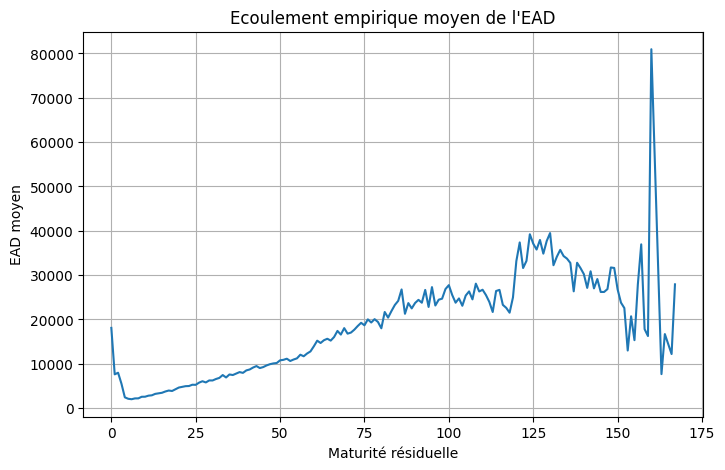

In [ ]:
structure_empirique = (
    df_model.groupby("B_RESMAT")
    .agg(
        EAD_mean=("EAD_before", "mean"),
        ER_mean=("remboursement_total", "mean")
    )
    .reset_index()
    .sort_values("B_RESMAT")
)

plt.figure(figsize=(8,5))
plt.plot(structure_empirique["B_RESMAT"],
         structure_empirique["EAD_mean"])
plt.xlabel("Maturité résiduelle")
plt.ylabel("EAD moyen")
plt.title("Ecoulement empirique moyen de l'EAD")
plt.grid(True)
plt.show()


In [56]:
prop = (
    ((df["E_EAD"] > 0) & (df["NBIMP"] > 0)).sum()
    / (df["NBIMP"] > 0).sum()
)

print("Proportion EAD>0 quand NBIMP>0 :", prop)


Proportion EAD>0 quand NBIMP>0 : 0.9943181818181818
